# Task 7.3 — Hahn-Echo

Two measurements were taken with the calibrated $\pi$-pulse from the Rabi analysis ($T_\pi = 475$ ns at $f_\mathrm{MW} = 2{,}7825$ GHz, $P_\mathrm{MW} = 0$ dB).

**Sequence:** $\text{Init} \;\to\; \pi/2 \;\to\; \tau_1 \;\to\; \pi \;\to\; \tau_2 \;\to\; \pi/2 \;\to\; \text{Readout}$.

The $\pi$-pulse at the centre refocuses static inhomogeneous dephasing — different NVs in the ensemble see slightly different local fields ($^{13}$C nuclear-spin bath, strain, $B_0$ inhomogeneity), so without the echo they fan out in the $xy$-plane on the timescale $T_2^*$. The $\pi$-pulse flips their phases so they re-converge if $\tau_2 = \tau_1$. What's left after refocusing is the *irreversible* decoherence on the much longer timescale $T_2$.

**Revival** ($\tau_1$ fixed, $\tau_2$ swept): expect an echo peak at $\tau_2 = \tau_1 = 2$ µs.

**Decay** ($\tau_1 = \tau_2 = \tau$ swept): expect the echo amplitude to decay with the total free evolution time $2\tau$, fit
$$
V(\tau) = A\,\exp\!\left[-(2\tau / T_2)^n\right] + C.
$$
The stretched exponent $n$ depends on the spectral character of the bath; for NV ensembles in natural-abundance $^{13}$C diamond, $n \approx 3$ is typical when the spin-bath dynamics is slow, $n \approx 1$ for a fast Markovian bath.


In [1]:
%matplotlib inline
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ECHO_DIR  = r"ALEXQUADRAT\20260122_150207_Hahnecho"
DECAY_DIR = r"ALEXQUADRAT\20260122_152347_Hahndecay"


def load_run(run_dir):
    with open(os.path.join(run_dir, "MeasurementParameters.json")) as f:
        params = json.load(f)["Parameters"]
    csv_dir = os.path.join(run_dir, "setCounter_['0']")
    csv = glob.glob(os.path.join(glob.escape(csv_dir), "*.csv"))[0]
    df = pd.read_csv(csv, sep=";")
    df.columns = [c.strip() for c in df.columns]
    tau_ns = df["programPulseSequenceAndRun"].to_numpy(float)
    V      = df["readOutput"].to_numpy(float)
    return params, tau_ns, V


p_echo,  tau_echo,  V_echo  = load_run(ECHO_DIR)
p_decay, tau_decay, V_decay = load_run(DECAY_DIR)

print("Echo (revival):")
print(f"  pi-pulse used: {p_echo['PI_Pulse_ns']} ns,  tau1 fixed = {p_echo['T1_ns']} ns")
print(f"  tau2 swept: {tau_echo.min():.0f}..{tau_echo.max():.0f} ns, step {np.median(np.diff(tau_echo)):.0f} ns")
print()
print("Decay (tau1 = tau2 = tau):")
print(f"  pi-pulse used: {p_decay['PI_Pulse_ns']} ns")
print(f"  tau swept: {tau_decay.min():.0f}..{tau_decay.max():.0f} ns, step {np.median(np.diff(tau_decay)):.0f} ns")


Echo (revival):
  pi-pulse used: 475 ns,  tau1 fixed = 2000 ns
  tau2 swept: 50..10050 ns, step 200 ns

Decay (tau1 = tau2 = tau):
  pi-pulse used: 475 ns
  tau swept: 200..10000 ns, step 200 ns


## Raw overview


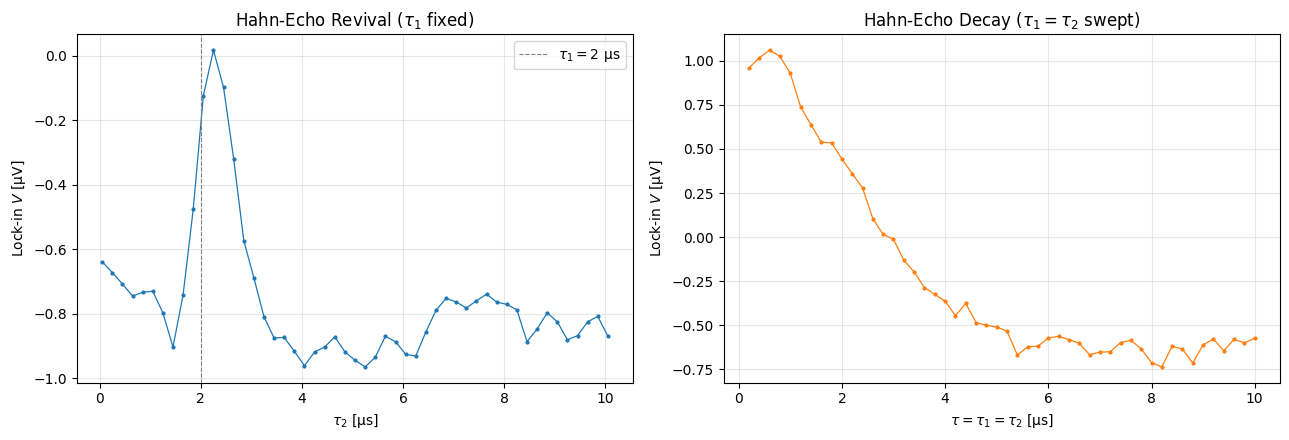

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(tau_echo/1e3, V_echo*1e6, ".-", lw=0.9, ms=4)
ax.axvline(p_echo["T1_ns"]/1e3, ls="--", color="0.5", lw=0.8, label=r"$\tau_1 = 2$ µs")
ax.set_xlabel(r"$\tau_2$ [µs]")
ax.set_ylabel(r"Lock-in $V$ [µV]")
ax.set_title(r"Hahn-Echo Revival ($\tau_1$ fixed)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(tau_decay/1e3, V_decay*1e6, ".-", lw=0.9, ms=4, color="C1")
ax.set_xlabel(r"$\tau = \tau_1 = \tau_2$ [µs]")
ax.set_ylabel(r"Lock-in $V$ [µV]")
ax.set_title(r"Hahn-Echo Decay ($\tau_1 = \tau_2$ swept)")
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Echo revival — Gaussian fit

At $\tau_2 = \tau_1$ the $\pi$-pulse refocuses the inhomogeneously dephased spins back into the bright $m_s=0$ state. In our lock-in convention the lock-in reads $V \propto (I_\text{off} - I_\text{res})$, so the *more spins in $m_s=0$* the *less negative* (in fact, near-zero) the signal becomes. The echo therefore manifests as a **positive peak above the dephased baseline**, not as a dip. We fit
$$
V(\tau_2) = A\,\exp\!\left[-\frac{(\tau_2 - \tau_0)^2}{2\sigma^2}\right] + C, \qquad A > 0.
$$
The FWHM of the revival is set by the static field inhomogeneity across the ensemble (a Gaussian distribution of detunings → Gaussian echo shape in $\tau_2 - \tau_1$).

Echo centre  tau0 = 2303 ± 26 ns   (set value: tau1 = 2000 ns)
Echo width   sigma = 343 ± 27 ns    FWHM = 808 ns
Echo height  A     = +0.857 ± 0.056 µV   (above baseline)
Baseline     C     = -0.833 µV


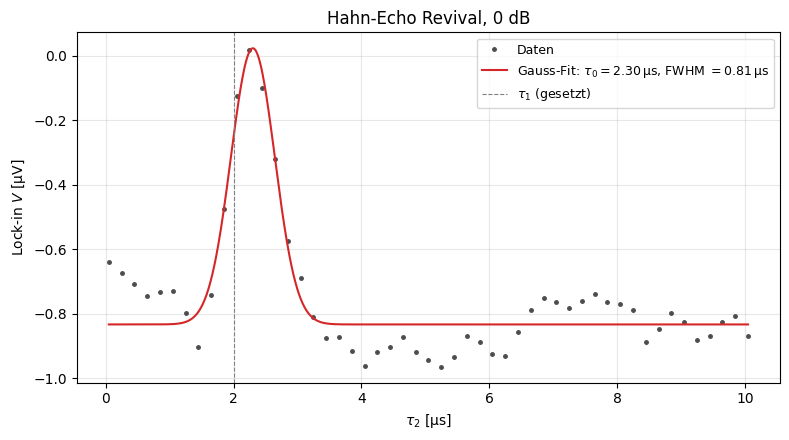

In [3]:
def gauss(tau, A, tau0, sigma, C):
    return A * np.exp(-((tau - tau0) ** 2) / (2 * sigma ** 2)) + C


# Echo refocuses spins back to bright m_s=0 → lock-in signal goes UP (less negative)
# at the revival, so A > 0, baseline C is far from the echo.
# Use baseline from points far from the expected revival; peak = most-positive point.
mask_far = np.abs(tau_echo - p_echo["T1_ns"]) > 3000   # > 3 µs from tau1
C0    = V_echo[mask_far].mean()
idx0  = int(np.argmax(V_echo))               # most-positive point (the echo peak)
A0    = V_echo[idx0] - C0                    # positive amplitude
tau00 = tau_echo[idx0]
sig0  = 500.0                                # echo is narrow (~few hundred ns)

popt, pcov = curve_fit(
    gauss, tau_echo, V_echo,
    p0=[A0, tau00, sig0, C0],
    bounds=([0, tau_echo.min(), 100, -np.inf],
            [np.inf, tau_echo.max(), 5000, np.inf]),
    maxfev=20000,
)
perr = np.sqrt(np.diag(pcov))
A, tau0, sigma, C = popt
fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

print(f"Echo centre  tau0 = {tau0:.0f} ± {perr[1]:.0f} ns   (set value: tau1 = {p_echo['T1_ns']} ns)")
print(f"Echo width   sigma = {sigma:.0f} ± {perr[2]:.0f} ns    FWHM = {fwhm:.0f} ns")
print(f"Echo height  A     = {A*1e6:+.3f} ± {perr[0]*1e6:.3f} µV   (above baseline)")
print(f"Baseline     C     = {C*1e6:.3f} µV")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tau_echo/1e3, V_echo*1e6, ".", ms=5, color="0.3", label="Daten")
tt = np.linspace(tau_echo.min(), tau_echo.max(), 1000)
ax.plot(tt/1e3, gauss(tt, *popt)*1e6, "-", color="C3", lw=1.5,
        label=fr"Gauss-Fit: $\tau_0 = {tau0/1e3:.2f}\,\mathrm{{µs}}$, FWHM $= {fwhm/1e3:.2f}\,\mathrm{{µs}}$")
ax.axvline(p_echo["T1_ns"]/1e3, ls="--", color="0.5", lw=0.8, label=r"$\tau_1$ (gesetzt)")
ax.set_xlabel(r"$\tau_2$ [µs]"); ax.set_ylabel(r"Lock-in $V$ [µV]")
ax.set_title("Hahn-Echo Revival, 0 dB")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Echo decay — stretched exponential

The decay measurement sweeps $\tau_1 = \tau_2 = \tau$, so the total free evolution time is $2\tau$. We fit
$$
V(\tau) = A\,\exp\!\left[-\left(\frac{2\tau}{T_2}\right)^{\!n}\right] + C,
$$
with the stretched exponent $n$ free. For comparison we also fit the constrained $n=1$ case (pure exponential).


Stretched fit:  T2 = 5848 ± 102 ns   n = 1.98 ± 0.10   SSR = 0.113 µV²
Pure  n=1 fit:  T2 = 5308 ± 400 ns                       SSR = 0.555 µV²


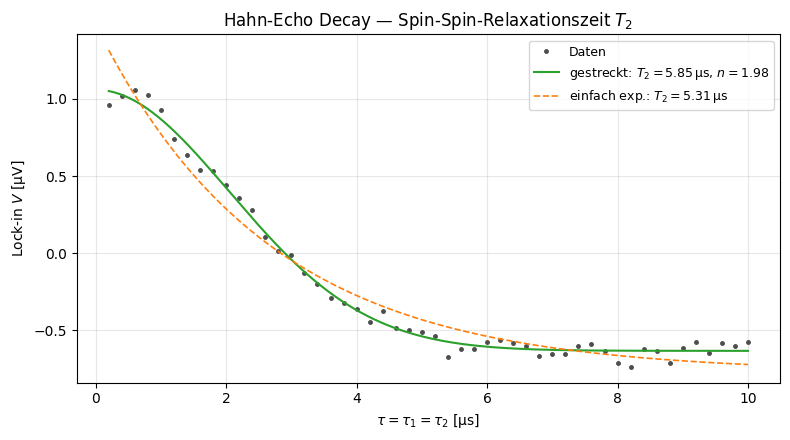

In [4]:
def stretched(tau, A, T2, n, C):
    return A * np.exp(-((2 * tau / T2) ** n)) + C

def pure_exp(tau, A, T2, C):
    return A * np.exp(-(2 * tau / T2)) + C


# Initial guesses
C0 = V_decay[-5:].mean()              # tail = baseline
A0 = V_decay[0] - C0
T20 = 5000.0

# Stretched
ps, cs = curve_fit(
    stretched, tau_decay, V_decay,
    p0=[A0, T20, 1.5, C0],
    bounds=([-np.inf, 100, 0.3, -np.inf],
            [ np.inf, 1e6, 5.0,  np.inf]),
    maxfev=20000,
)
ps_err = np.sqrt(np.diag(cs))

# Pure exp (for comparison)
pe, ce = curve_fit(
    pure_exp, tau_decay, V_decay,
    p0=[A0, T20, C0],
    bounds=([-np.inf, 100, -np.inf], [np.inf, 1e6, np.inf]),
    maxfev=20000,
)
pe_err = np.sqrt(np.diag(ce))

ssr_s = np.sum((V_decay - stretched(tau_decay, *ps))**2)
ssr_e = np.sum((V_decay - pure_exp(tau_decay,  *pe))**2)

print(f"Stretched fit:  T2 = {ps[1]:.0f} ± {ps_err[1]:.0f} ns   n = {ps[2]:.2f} ± {ps_err[2]:.2f}   SSR = {ssr_s*1e12:.3f} µV²")
print(f"Pure  n=1 fit:  T2 = {pe[1]:.0f} ± {pe_err[1]:.0f} ns                       SSR = {ssr_e*1e12:.3f} µV²")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tau_decay/1e3, V_decay*1e6, ".", ms=5, color="0.3", label="Daten")
tt = np.linspace(tau_decay.min(), tau_decay.max(), 1000)
ax.plot(tt/1e3, stretched(tt, *ps)*1e6, "-", color="C2", lw=1.5,
        label=fr"gestreckt: $T_2 = {ps[1]/1e3:.2f}\,\mathrm{{µs}}$, $n = {ps[2]:.2f}$")
ax.plot(tt/1e3, pure_exp(tt, *pe)*1e6, "--", color="C1", lw=1.2,
        label=fr"einfach exp.: $T_2 = {pe[1]/1e3:.2f}\,\mathrm{{µs}}$")
ax.set_xlabel(r"$\tau = \tau_1 = \tau_2$ [µs]")
ax.set_ylabel(r"Lock-in $V$ [µV]")
ax.set_title(r"Hahn-Echo Decay — Spin-Spin-Relaxationszeit $T_2$")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Discussion

**Three timescales.** The lab manual distinguishes:

- $T_1$ — *longitudinal/lattice* relaxation, the lifetime of population in $m_s = \pm 1$ before phonon-assisted decay to $m_s = 0$. Typically ms-scale for NV at room temperature.
- $T_2$ — *transverse / spin-spin* relaxation, the irreversible dephasing time that the Hahn echo measures. Limited by *dynamic* magnetic noise from the $^{13}$C nuclear bath and other electron spins (P1 centres) that the refocusing $\pi$-pulse cannot un-do. Typically a few µs for NV ensembles in natural-abundance diamond.
- $T_2^*$ — *inhomogeneous* dephasing time, dominated by the *static* spread of resonance frequencies across the ensemble. Much shorter than $T_2$ (often by 1–2 orders of magnitude). This is the timescale the Rabi-envelope decay $T_R$ approaches.

Our Rabi-envelope $T_R \approx 4{,}6$ µs at 0 dB is therefore an upper bound on $T_2^*$ (it also contains MW-field noise and amplifier drift). The Hahn echo $T_2$ should be **longer** than $T_2^*$ — that is the whole point of the refocusing $\pi$-pulse.

**Echo revival.** The Gaussian width of the revival reflects the spread of effective Larmor frequencies in the ensemble: a broader static distribution → sharper, narrower revival (less time before different NVs dephase relative to each other again after the $\pi$-pulse). So the FWHM extracted above is essentially a measurement of $T_2^*$.

**Stretched exponential.** $n = 1$ corresponds to a fast Markovian bath; larger $n$ (up to $n = 3$) indicates a slowly fluctuating bath where each NV sees an approximately static field over the echo window but the field itself drifts between experiments. NV in $^{13}$C-natural diamond is typically in the slow-bath regime.
